# House Price Prediction — Model Training & Evaluation

This notebook covers the complete model-training experimentation workflow:

1. Load the cleaned dataset
2. Separate features and target
3. Create training and holdout test sets
4. Identify numerical and categorical features
5. Build preprocessing pipelines
6. Compare baseline regression models
7. Evaluate models using 5-fold cross-validation
8. Tune the best baseline model (Lasso Regression)
9. Compare baseline and tuned Lasso Regression
10. Perform final holdout evaluation
11. Save the final model for experimentation

In [94]:
# ==========================================
# Data Manipulation
# ==========================================

import pandas as pd
import numpy as np


# ==========================================
# Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================
# Model Selection
# ==========================================

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    RandomizedSearchCV
)


# ==========================================
# Data Preprocessing
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)


# ==========================================
# Regression Models
# ==========================================

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor


# ==========================================
# Model Evaluation
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)


# ==========================================
# Model Saving
# ==========================================

import pickle


# ==========================================
# Ignore Warnings
# ==========================================

import warnings

warnings.filterwarnings("ignore")

In [95]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("raw.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (545, 13)


In [96]:
# ==========================================
# Preview Dataset
# ==========================================

display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [97]:
# ==========================================
# Feature Engineering
# ==========================================

df["total_rooms"] = (
    df["bedrooms"] + df["bathrooms"]
)

df["area_per_bedroom"] = (
    df["area"] /
    df["bedrooms"].replace(0, np.nan)
)

df["area_per_bathroom"] = (
    df["area"] /
    df["bathrooms"].replace(0, np.nan)
)

df["amenity_count"] = (
    (df["mainroad"] == "yes").astype(int)
    + (df["guestroom"] == "yes").astype(int)
    + (df["basement"] == "yes").astype(int)
    + (df["hotwaterheating"] == "yes").astype(int)
    + (df["airconditioning"] == "yes").astype(int)
    + (df["prefarea"] == "yes").astype(int)
)

print("Feature engineering completed.")

display(
    df[
        [
            "area",
            "bedrooms",
            "bathrooms",
            "total_rooms",
            "area_per_bedroom",
            "area_per_bathroom",
            "amenity_count",
            "price"
        ]
    ].head()
)

Feature engineering completed.


,area,bedrooms,bathrooms,total_rooms,area_per_bedroom,area_per_bathroom,amenity_count,price
0,7420,4,2,6,1855.0,3710.0,3,13300000
1,8960,4,4,8,2240.0,2240.0,2,12250000
2,9960,3,2,5,3320.0,4980.0,3,12250000
3,7500,4,2,6,1875.0,3750.0,4,12215000
4,7420,4,1,5,1855.0,7420.0,4,11410000


In [98]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              545 non-null    int64  
 1   area               545 non-null    int64  
 2   bedrooms           545 non-null    int64  
 3   bathrooms          545 non-null    int64  
 4   stories            545 non-null    int64  
 5   mainroad           545 non-null    str    
 6   guestroom          545 non-null    str    
 7   basement           545 non-null    str    
 8   hotwaterheating    545 non-null    str    
 9   airconditioning    545 non-null    str    
 10  parking            545 non-null    int64  
 11  prefarea           545 non-null    str    
 12  furnishingstatus   545 non-null    str    
 13  total_rooms        545 non-null    int64  
 14  area_per_bedroom   545 non-null    float64
 15  area_per_bathroom  545 non-null    float64
 16  amenity_count      545 non-null    in

In [99]:
# ==========================================
# Missing Values
# ==========================================

missing_values = df.isnull().sum()

display(missing_values)

price                0
area                 0
bedrooms             0
bathrooms            0
stories              0
mainroad             0
guestroom            0
basement             0
hotwaterheating      0
airconditioning      0
parking              0
prefarea             0
furnishingstatus     0
total_rooms          0
area_per_bedroom     0
area_per_bathroom    0
amenity_count        0
dtype: int64

In [100]:
# ==========================================
# Duplicate Rows
# ==========================================

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [101]:
# ==========================================
# Separate Features and Target
# ==========================================

X = df.drop(
    columns=["price"]
)

y = df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (545, 16)
Target shape: (545,)


In [102]:
# ==========================================
# Log Transform Target
# ==========================================

y_log = np.log1p(y)

print(
    "Original target skewness :",
    y.skew()
)

print(
    "Log target skewness      :",
    y_log.skew()
)

Original target skewness : 1.2122388370279802
Log target skewness      : 0.14086281102108905


In [103]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train_log.shape)
print("y_test :", y_test_log.shape)

X_train: (436, 16)
X_test : (109, 16)
y_train: (436,)
y_test : (109,)


In [104]:
# ==========================================
# Original Target Values
# Used only for final evaluation
# ==========================================

y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

print("Original target values restored for final evaluation.")

Original target values restored for final evaluation.


In [105]:
# ==========================================
# Identify Numerical and Categorical Features
# ==========================================

numerical_features = X.select_dtypes(
    exclude="object"
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'total_rooms', 'area_per_bedroom', 'area_per_bathroom', 'amenity_count']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [106]:
# ==========================================
# Numerical Preprocessing Pipeline
# ==========================================

num_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [107]:
# ==========================================
# Categorical Preprocessing Pipeline
# ==========================================

cat_pipeline = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [108]:
# ==========================================
# Combined Preprocessor
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            num_pipeline,
            numerical_features
        ),
        (
            "cat",
            cat_pipeline,
            categorical_features
        )
    ]
)

print(
    "Preprocessing pipeline created successfully."
)

Preprocessing pipeline created successfully.


In [109]:
# ==========================================
# Baseline Regression Models
# ==========================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=0.001,
        max_iter=10000
    ),

    "ElasticNet": ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000
    ),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        thread_count=1
    )
}

In [110]:
# ==========================================
# Train Baseline Models
# ==========================================

baseline_results = []

trained_models = {}

for model_name, model in models.items():

    print(f"Training: {model_name}")

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train_log
    )

    trained_models[
        model_name
    ] = pipeline

    # ======================================
    # Log-scale Predictions
    # ======================================

    y_train_pred_log = pipeline.predict(
        X_train
    )

    y_test_pred_log = pipeline.predict(
        X_test
    )

    # ======================================
    # Log-scale Metrics
    # ======================================

    train_r2 = r2_score(
        y_train_log,
        y_train_pred_log
    )

    test_r2 = r2_score(
        y_test_log,
        y_test_pred_log
    )

    # ======================================
    # Convert Predictions Back to Price
    # ======================================

    y_test_pred = np.expm1(
        y_test_pred_log
    )

    # ======================================
    # Real-world Price Metrics
    # ======================================

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )

    baseline_results.append({
        "Model": model_name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "MAE": test_mae,
        "RMSE": test_rmse
    })

baseline_results_df = pd.DataFrame(
    baseline_results
)

baseline_results_df = baseline_results_df.sort_values(
    by="Test R2",
    ascending=False
).reset_index(drop=True)

Training: Linear Regression
Training: Ridge Regression
Training: Lasso Regression
Training: ElasticNet
Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: Gradient Boosting
Training: XGBoost
Training: CatBoost


In [111]:
# ==========================================
# Baseline Model Leaderboard
# ==========================================

display(
    baseline_results_df.style.format({
        "Train R2": "{:.4f}",
        "Test R2": "{:.4f}",
        "MAE": "₹{:,.2f}",
        "RMSE": "₹{:,.2f}"
    })
)

,Model,Train R2,Test R2,MAE,RMSE
0,Random Forest,0.9469,0.6770,"₹963,598.46","₹1,360,424.12"
1,Linear Regression,0.7048,0.6739,"₹965,630.91","₹1,311,122.40"
2,Ridge Regression,0.7048,0.6735,"₹964,798.45","₹1,311,769.58"
3,ElasticNet,0.7046,0.6717,"₹965,135.16","₹1,314,529.96"
4,Lasso Regression,0.7041,0.6696,"₹963,686.71","₹1,317,599.87"
5,CatBoost,0.8898,0.6673,"₹963,276.36","₹1,378,817.17"
6,XGBoost,0.9424,0.6578,"₹992,690.21","₹1,380,867.60"
7,Gradient Boosting,0.8680,0.6474,"₹982,826.40","₹1,433,240.60"
8,Extra Trees,0.9948,0.6360,"₹1,001,597.82","₹1,385,829.30"
9,Decision Tree,0.9948,0.5612,"₹1,086,482.20","₹1,521,303.67"


In [112]:
# ==========================================
# Best Model on Original Holdout Split
# ==========================================

best_holdout_model = baseline_results_df.iloc[0]

print("=" * 60)
print("BEST MODEL — ORIGINAL HOLDOUT")
print("=" * 60)

print(
    "Model:",
    best_holdout_model["Model"]
)

print(
    f"Test R2: "
    f"{best_holdout_model['Test R2']:.4f}"
)

print("=" * 60)

BEST MODEL — ORIGINAL HOLDOUT
Model: Random Forest
Test R2: 0.6770


## 5-Fold Cross-Validation

The initial model comparison used a single train-test split.

To obtain a more robust estimate of model performance, the models are
now evaluated using 5-fold cross-validation on the training dataset.

The holdout test set will not be used to select the model.
It will be used only once for the final evaluation.

In [113]:
# ==========================================
# 5-Fold Cross Validation
# ==========================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

print(
    "5-Fold Cross Validation configured."
)

5-Fold Cross Validation configured.


In [115]:
# ==========================================
# Cross-Validation Model Comparison
# ==========================================

cv_results = []

for model_name, model in models.items():

    print(f"Evaluating: {model_name}")

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train_log,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
        error_score="raise"
    )

    mean_cv_r2 = scores[
        "test_r2"
    ].mean()

    std_cv_r2 = scores[
        "test_r2"
    ].std()

    mean_cv_mae = -scores[
        "test_mae"
    ].mean()

    mean_cv_rmse = np.sqrt(
        -scores[
            "test_mse"
        ].mean()
    )

    mean_train_r2 = scores[
        "train_r2"
    ].mean()

    cv_results.append({
    "Model": model_name,
    "CV R2 (Log)": mean_cv_r2,
    "CV R2 Std": std_cv_r2,
    "CV MAE (Log)": mean_cv_mae,
    "CV RMSE (Log)": mean_cv_rmse,
    "Train R2 (Log)": mean_train_r2
    })

cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df = cv_results_df.sort_values(
    by="CV R2 (Log)",
    ascending=False
).reset_index(drop=True)

Evaluating: Linear Regression
Evaluating: Ridge Regression
Evaluating: Lasso Regression
Evaluating: ElasticNet
Evaluating: Decision Tree
Evaluating: Random Forest
Evaluating: Extra Trees
Evaluating: Gradient Boosting
Evaluating: XGBoost
Evaluating: CatBoost


In [132]:
# ==========================================
# 5-Fold CV Leaderboard
# ==========================================

display(
    cv_results_df.style.format({
        "CV R2 (Log)": "{:.4f}",
        "CV R2 Std": "{:.4f}",
        "CV MAE (Log)": "{:.4f}",
        "CV RMSE (Log)": "{:.4f}",
        "Train R2 (Log)": "{:.4f}"
    })
)

,Model,CV R2 (Log),CV R2 Std,CV MAE (Log),CV RMSE (Log),Train R2 (Log)
0,Lasso Regression,0.6736,0.0366,0.1541,0.1991,0.7067
1,ElasticNet,0.6725,0.0372,0.1542,0.1995,0.7072
2,Ridge Regression,0.6705,0.0376,0.1547,0.2001,0.7074
3,Linear Regression,0.6700,0.0381,0.1548,0.2002,0.7074
4,CatBoost,0.6518,0.0447,0.1554,0.2055,0.9034
5,Gradient Boosting,0.6315,0.0478,0.1603,0.2113,0.8840
6,XGBoost,0.6299,0.0566,0.1615,0.2117,0.9553
7,Random Forest,0.6203,0.0659,0.1613,0.2140,0.9456
8,Extra Trees,0.5988,0.0393,0.1665,0.2209,0.9953
9,Decision Tree,0.2639,0.1648,0.2265,0.2971,0.9953


In [133]:
# ==========================================
# Best Model from 5-Fold CV
# ==========================================

best_cv_row = cv_results_df.iloc[0]

best_cv_model_name = best_cv_row["Model"]

best_cv_r2 = best_cv_row["CV R2 (Log)"]

print("=" * 60)
print("BEST MODEL — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

print(
    f"Model : {best_cv_model_name}"
)

print(
    f"CV R2 : {best_cv_r2:.4f}"
)

print("=" * 60)

BEST MODEL — 5-FOLD CROSS-VALIDATION
Model : Lasso Regression
CV R2 : 0.6736


In [134]:
# ==========================================
# Lasso Pipeline for Tuning
# ==========================================

lasso_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Lasso(
                max_iter=10000
            )
        )
    ]
)

In [135]:
# ==========================================
# Lasso Hyperparameter Search Space
# ==========================================

lasso_param_grid = {
    "model__alpha": np.logspace(
        -5,
        1,
        50
    )
}

In [136]:
# ==========================================
# Lasso Randomized Search
# ==========================================

lasso_search = RandomizedSearchCV(
    estimator=lasso_pipeline,
    param_distributions=lasso_param_grid,
    n_iter=30,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting Lasso hyperparameter tuning...")

lasso_search.fit(
    X_train,
    y_train_log
)

print("Lasso hyperparameter tuning completed.")

Starting Lasso hyperparameter tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Lasso hyperparameter tuning completed.


In [137]:
# ==========================================
# Best Lasso Parameters
# ==========================================

print("=" * 70)
print("BEST LASSO PARAMETERS")
print("=" * 70)

for parameter, value in lasso_search.best_params_.items():
    print(f"{parameter}: {value}")

print("=" * 70)

tuned_lasso_cv_r2 = lasso_search.best_score_

print(
    f"Best Lasso CV R2: "
    f"{tuned_lasso_cv_r2:.4f}"
)

BEST LASSO PARAMETERS
model__alpha: 0.0021209508879201904
Best Lasso CV R2: 0.6755


In [138]:
# ==========================================
# Baseline vs Tuned Lasso
# ==========================================

baseline_lasso_cv_r2 = cv_results_df.loc[
    cv_results_df["Model"] == "Lasso Regression",
    "CV R2 (Log)"
].iloc[0]

improvement = (
    tuned_lasso_cv_r2
    - baseline_lasso_cv_r2
)

print("=" * 70)
print("LASSO TUNING RESULT")
print("=" * 70)

print(
    f"Baseline Lasso CV R2 : "
    f"{baseline_lasso_cv_r2:.4f}"
)

print(
    f"Tuned Lasso CV R2    : "
    f"{tuned_lasso_cv_r2:.4f}"
)

print(
    f"Improvement          : "
    f"{improvement:+.4f}"
)

print("=" * 70)

LASSO TUNING RESULT
Baseline Lasso CV R2 : 0.6736
Tuned Lasso CV R2    : 0.6755
Improvement          : +0.0019


In [139]:
# ==========================================
# Final Model Selection
# ==========================================

if tuned_lasso_cv_r2 > baseline_lasso_cv_r2:

    final_model = lasso_search.best_estimator_

    final_model_name = "Tuned Lasso Regression"

    final_cv_r2 = tuned_lasso_cv_r2

else:

    final_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                Lasso(
                    alpha=0.001,
                    max_iter=10000
                )
            )
        ]
    )

    final_model_name = "Baseline Lasso Regression"

    final_cv_r2 = baseline_lasso_cv_r2


print("=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)

print(
    f"Selected Model : {final_model_name}"
)

print(
    f"CV R2          : {final_cv_r2:.4f}"
)

print("=" * 70)

FINAL MODEL SELECTION
Selected Model : Tuned Lasso Regression
CV R2          : 0.6755


In [140]:
# ==========================================
# Train Final Model
# ==========================================

final_model.fit(
    X_train,
    y_train_log
)

print(
    "Final model trained successfully."
)

Final model trained successfully.


In [141]:
# ==========================================
# Final Predictions
# ==========================================

predicted_log_price_train = (
    final_model.predict(X_train)
)

predicted_log_price_test = (
    final_model.predict(X_test)
)

# Convert log-price back to original price
predicted_price_train = np.expm1(
    predicted_log_price_train
)

predicted_price_test = np.expm1(
    predicted_log_price_test
)

In [142]:
# ==========================================
# Final Holdout Evaluation
# ==========================================

final_train_r2 = r2_score(
    y_train,
    predicted_price_train
)

final_test_r2 = r2_score(
    y_test,
    predicted_price_test
)

final_test_mae = mean_absolute_error(
    y_test,
    predicted_price_test
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predicted_price_test
    )
)

final_test_mape = (
    mean_absolute_percentage_error(
        y_test,
        predicted_price_test
    ) * 100
)


print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(
    f"Model        : {final_model_name}"
)

print(
    f"CV R2        : {final_cv_r2:.4f}"
)

print(
    f"Train R2     : {final_train_r2:.4f}"
)

print(
    f"Test R2      : {final_test_r2:.4f}"
)

print(
    f"Test MAE     : ₹{final_test_mae:,.2f}"
)

print(
    f"Test RMSE    : ₹{final_test_rmse:,.2f}"
)

print(
    f"Test MAPE    : {final_test_mape:.2f}%"
)

print("=" * 70)

FINAL MODEL PERFORMANCE
Model        : Tuned Lasso Regression
CV R2        : 0.6755
Train R2     : 0.6898
Test R2      : 0.6536
Test MAE     : ₹959,997.87
Test RMSE    : ₹1,323,252.93
Test MAPE    : 20.53%


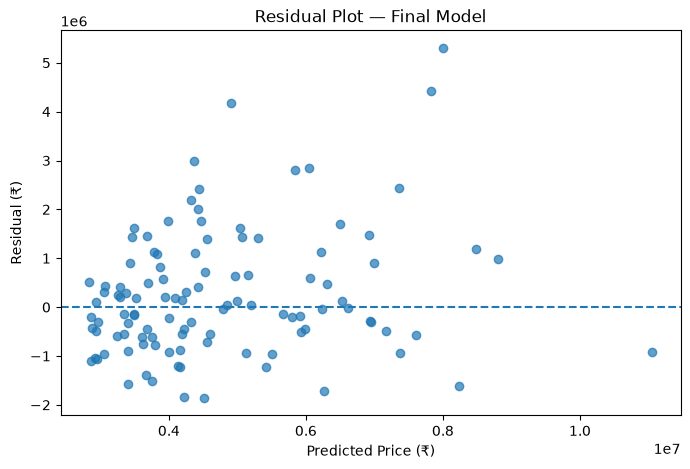

In [143]:
# ==========================================
# Residual Analysis
# ==========================================

residuals = (
    y_test
    - predicted_price_test
)

plt.figure(figsize=(8, 5))

plt.scatter(
    predicted_price_test,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price (₹)")
plt.ylabel("Residual (₹)")
plt.title("Residual Plot — Final Model")

plt.show()

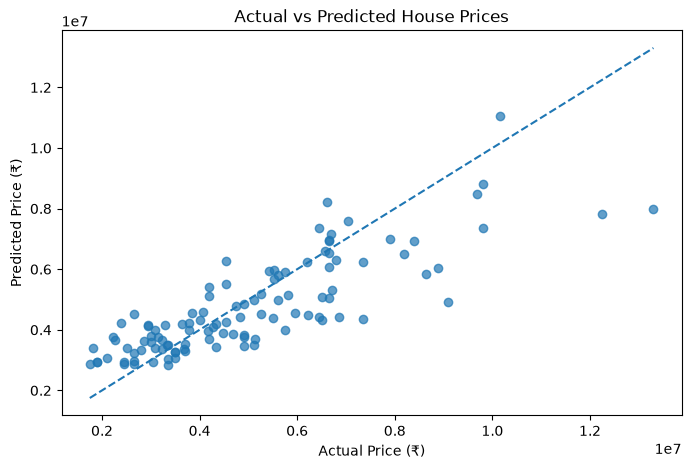

In [144]:
# ==========================================
# Actual vs Predicted
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    predicted_price_test,
    alpha=0.7
)

min_value = min(
    y_test.min(),
    predicted_price_test.min()
)

max_value = max(
    y_test.max(),
    predicted_price_test.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [145]:
# ==========================================
# Prediction Error Analysis
# ==========================================

prediction_results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predicted_price_test
})

prediction_results["Absolute Error"] = (
    abs(
        prediction_results["Actual Price"]
        - prediction_results["Predicted Price"]
    )
)

prediction_results["Percentage Error"] = (
    prediction_results["Absolute Error"]
    / prediction_results["Actual Price"]
    * 100
)

display(
    prediction_results.head(10)
)

,Actual Price,Predicted Price,Absolute Error,Percentage Error
0,4060000.0,4.601048e+06,5.410476e+05,13.326296
1,6650000.0,6.955864e+06,3.058636e+05,4.599453
2,3710000.0,3.293999e+06,4.160012e+05,11.212971
3,6440000.0,4.427053e+06,2.012947e+06,31.256944
4,2800000.0,3.346826e+06,5.468258e+05,19.529494
5,4900000.0,3.454932e+06,1.445068e+06,29.491179
6,5250000.0,5.198107e+06,5.189349e+04,0.988447
7,4543000.0,6.264560e+06,1.721560e+06,37.894776
8,2450000.0,2.872501e+06,4.225011e+05,17.244945
9,3353000.0,2.831517e+06,5.214828e+05,15.552723


In [146]:
# ==========================================
# Save Final Model
# ==========================================

model_path = "final_house_price_model.pkl"

with open(
    model_path,
    "wb"
) as file:

    pickle.dump(
        final_model,
        file
    )

print(
    f"Model saved successfully: {model_path}"
)

Model saved successfully: final_house_price_model.pkl


In [147]:
# ==========================================
# Save Cross-Validation Leaderboard
# ==========================================

cv_results_df.to_csv(
    "model_comparison_cv.csv",
    index=False
)

print(
    "CV leaderboard saved: "
    "model_comparison_cv.csv"
)

CV leaderboard saved: model_comparison_cv.csv


## Final Experiment Conclusion

The initial single train-test split was used as an exploratory baseline comparison of the regression models. However, model selection was not based solely on this single holdout result.

To obtain a more reliable estimate of model performance, 5-fold cross-validation was performed on the training dataset. The target variable was log-transformed using `np.log1p()` to reduce the effect of target-price skewness. Under this cross-validation setup, **Lasso Regression achieved the highest baseline mean R² of 0.6736** among the evaluated models.

Lasso Regression was subsequently tuned using `RandomizedSearchCV`. The tuned model achieved a cross-validation R² of **0.6755**, representing an improvement of **0.0019** over the baseline Lasso model. Although the improvement was small, the tuned configuration was selected because it provided the best cross-validation performance.

The selected final model was then retrained using the complete training portion of the dataset. Predictions were generated in log-price space and converted back to the original house-price scale using `np.expm1()` before calculating the final MAE, RMSE, R², and MAPE metrics.

The holdout test set was kept separate from model selection and hyperparameter tuning and was used only for the final performance evaluation. This provides a less biased estimate of how the selected model is expected to perform on unseen data.

Overall, the experiment demonstrates a structured model-development workflow consisting of feature engineering, preprocessing, baseline model comparison, cross-validation, hyperparameter tuning, final model selection, holdout evaluation, and model persistence.

The final model and cross-validation results were saved for further experimentation and deployment.
